In [13]:
!pip install --force-reinstall numpy scipy scikit-learn
!pip install cleanlab --force-reinstall --no-deps

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 308.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 290.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 239.4 MB/s eta 0:00:00
    tinycss2 (>=1.1.0<1.2) ; extra == 'css'
             ~~~~~~~~^
    torch (>=1.10.0+cu113<1.11.0)
           ~~~~~~~~^
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.5.0
    Uninstalling threadpoolctl-3.5.0:
      Successfully uninstalled threadpoolctl-3.5.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
  Attempting uninstall: joblib
    Found existing installation: joblib 1.4.2
    Uninstalling joblib-1.4.2:
      Successfully uninstalled joblib-1.4.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Un

# Initialization


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os


from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import NearestNeighbors

from cleanlab import Datalab

SEED = 1994
np.random.seed(SEED)
random.seed(SEED)



/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
NUM_CV_FOLDS = 5

LABEL_NAMES = {
    0: "Sedentary",
    1: "Standing",
    2: "Stepping",
    3: "Lying",
    4: "Seated_Transport",
    5: "Transition-active",
    6: "Transition-mixed",
}

In [6]:
import os
data_path = "/niddk-data-central/mae_hr/rise_moca_4AP_20s_transition"
df_full = pd.read_csv(os.path.join(data_path, "pred_gt_df/pred_gt_df_test.csv"), index_col=0)
df_full = df_full.drop(columns=['domfreq_x', 'domfreq_y', 'domfreq_z', "domfreq_vm", "autocorr_x", "autocorr_y", "autocorr_z", "autocorr_vm"])
print(f"Full dataset shape: {df_full.shape}")
FEATURE_COLS = [c for c in df_full.columns if c not in ("pred", "truth")]
print(FEATURE_COLS)

Full dataset shape: (3532068, 46)
['mean_x', 'mean_y', 'mean_z', 'mean_vm', 'std_x', 'std_y', 'std_z', 'std_vm', 'min_x', 'min_y', 'min_z', 'min_vm', 'max_x', 'max_y', 'max_z', 'max_vm', 'median_x', 'median_y', 'median_z', 'median_vm', 'rms_x', 'rms_y', 'rms_z', 'rms_vm', 'skew_x', 'skew_y', 'skew_z', 'skew_vm', 'kurt_x', 'kurt_y', 'kurt_z', 'kurt_vm', 'iqr_x', 'iqr_y', 'iqr_z', 'iqr_vm', 'mad_x', 'mad_y', 'mad_z', 'mad_vm', 'specenergy_x', 'specenergy_y', 'specenergy_z', 'specenergy_vm']


In [7]:
IS_FULL = True
if IS_FULL:
    df = df_full
else:
    frames = []
    for cls in sorted(df_full["truth"].unique()):
        cls_df = df_full[df_full["truth"] == cls]
        n = min(SAMPLES_PER_CLASS, len(cls_df))
        frames.append(cls_df.sample(n=n, random_state=SEED))

    df_sampled = pd.concat(frames).sample(frac=1, random_state=SEED).reset_index(drop=True)
    print(f"Sampled dataset shape: {df_sampled.shape}")
    print("\nPer-class counts:")
    for cls, name in LABEL_NAMES.items():
        count = (df_sampled["truth"] == cls).sum()
        print(f"  {cls}  {name:>20s}: {count:>5}")
    df = df_sampled

X_raw  = df[FEATURE_COLS].values
labels = df["truth"].values.astype(int)




In [8]:
# Check for NaNs
n_nan = np.isnan(X_raw).sum()
rows_w_nan = np.isnan(X_raw).any(axis=1)
n_rows_w_nan = rows_w_nan.sum()
print(f"Total NaN values in features: {n_nan}")
print(f"Rows with NaN values in features: {n_rows_w_nan}")

X = X_raw.copy()
X = X_raw[rows_w_nan == False]
labels = labels[rows_w_nan == False]

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)  

print(f"X shape : {X.shape}")
print(f"labels  : {labels.shape}  unique={np.unique(labels)}")

Total NaN values in features: 0
Rows with NaN values in features: 0
X shape : (3532068, 44)
labels  : (3532068,)  unique=[0 1 2 3 4 5 6]


# CV for prediction probability


In [ ]:
# HistGradientBoostingClassifier 
clf = HistGradientBoostingClassifier(random_state=SEED)
cv  = StratifiedKFold(n_splits=NUM_CV_FOLDS, shuffle=True, random_state=SEED)

print(f"Running {NUM_CV_FOLDS}-fold cross-validation...")
pred_probs = cross_val_predict(
    clf, X, labels,
    cv=cv,
    method="predict_proba",
)

print(f"pred_probs shape : {pred_probs.shape}")
print(f"Row-sum check    : {pred_probs.sum(axis=1)[:5].round(4)}")

Running 5-fold cross-validation...


# KNN

In [ ]:
run_again = False
if run_again:
    knn = NearestNeighbors(metric="euclidean")
    knn.fit(X)
    knn_graph = knn.kneighbors_graph(mode="distance")
    save_npz(os.path.join(data_path, 'knn_graph.npz'), knn_graph)
else:
    from scipy.sparse import save_npz, load_npz
    knn_graph = load_npz(os.path.join(data_path, 'pred_gt_df/knn_graph_test.npz'))


print(f"KNN graph shape: {knn_graph.shape}")


KNN graph shape: (3532068, 3532068)


# Cleanlab Datalab

In [ ]:
lab = Datalab(data={"X": X, "y": labels}, label_name="y")

lab.find_issues(
    pred_probs=pred_probs,
    knn_graph=knn_graph,
)


ImportError: Datalab is not available due to missing dependencies. To install Datalab, run `pip install 'cleanlab[datalab]'`. (raised when trying to call with args: (), kwargs: {'data': {'X': array([[ 0.34868083,  0.91559992,  1.44166563, ..., -0.7028475 ,
         0.73468416, -0.32093573],
       [-0.06616038,  1.04606612,  1.55200952, ..., -0.55728676,
         1.01616592, -0.5353804 ],
       [-0.07654934,  1.067642  ,  1.52399664, ..., -0.50228289,
         0.93432648, -0.65641602],
       ...,
       [ 0.94310445,  1.2168642 , -0.94812904, ..., -0.07947487,
         0.14803426, -0.07986129],
       [ 0.88127248,  1.22453544, -0.9615587 , ..., -0.05450054,
         0.1796139 , -0.04988791],
       [ 0.93233467,  1.23384288, -0.92697395, ..., -0.02587105,
         0.10310877, -0.04383732]]), 'y': array([6, 0, 0, ..., 4, 4, 4])}, 'label_name': 'y'})

In [ ]:
lab.report()

NameError: name 'lab' is not defined

# Label Issues


In [ ]:
lab.get_issue_summary()

NameError: name 'lab' is not defined

In [ ]:
MoCA_pred = df['pred'].values.astype(int)
label_issues = lab.get_issues("label").copy()
label_issues['MoCA_pred'] = MoCA_pred

label_issues['given_label_chr'] = label_issues['given_label'].map(LABEL_NAMES)
label_issues['MoCA_pred_chr'] = label_issues['MoCA_pred'].map(LABEL_NAMES)
label_issues['predicted_label_chr'] = label_issues['predicted_label'].map(LABEL_NAMES)
label_issues.to_csv("/niddk-data-central/mae_hr/rise_moca_4AP_20s_transition/pred_gt_df/cleanlab_df_test.csv") 

NameError: name 'lab' is not defined

In [ ]:
flagged = label_issues[label_issues["is_label_issue"]].sort_values("label_score")
flagged.sort_values("label_score")
print(f"Flagged: {len(flagged)} / {len(labels)}  ({100*len(flagged)/len(labels):.1f}%)")

flagged = flagged.reset_index()
flagged
flagged.to_csv("/niddk-data-central/mae_hr/rise_moca_4AP_20s_transition/cleanlab_flagged.csv") 

Flagged: 656254 / 3532068  (18.6%)


In [29]:
cleanlab_indices = flagged["index"].values
cleanlab_indices

array([ 257577,  257619, 3030607, ..., 2639536,  282094, 2517433])

In [41]:
import torch
test = torch.Tensor(flagged.reset_index(drop=True)[['given_label', 'predicted_label']].values)
print(flagged)
test_indices = np.array([1,2,3,4,5])
test_test = test[test_indices]


          index  is_label_issue  label_score  given_label  predicted_label  \
0        257577            True     0.000000            2                0   
1        257619            True     0.000000            2                5   
2       3030607            True     0.000000            2                4   
3        257580            True     0.000000            2                0   
4        257576            True     0.000000            2                5   
...         ...             ...          ...          ...              ...   
656249  2581725            True     0.492411            0                3   
656250  3492282            True     0.492655            0                3   
656251  2639536            True     0.492885            0                3   
656252   282094            True     0.492911            0                3   
656253  2517433            True     0.494096            0                3   

        MoCA_pred given_label_chr MoCA_pred_chr predicted_label

In [42]:
test_test

tensor([[2., 5.],
        [2., 4.],
        [2., 0.],
        [2., 5.],
        [2., 0.]])

In [26]:
# Per-class breakdown
print("Label issues per class:")
for cls, name in LABEL_NAMES.items():
    in_class  = label_issues[label_issues["given_label_chr"] == name]
    n_flagged = in_class["is_label_issue"].sum()
    n_total   = len(in_class)
    pct = 100 * n_flagged / n_total if n_total > 0 else 0
    print(f"  {cls}  {name:>20s}:  {n_flagged:>4} / {n_total}  ({pct:.1f}%)")

Label issues per class:
  0             Sedentary:  105323 / 1987853  (5.3%)
  1              Standing:  193873 / 519432  (37.3%)
  2              Stepping:  35149 / 101467  (34.6%)
  3                 Lying:  89655 / 145919  (61.4%)
  4      Seated_Transport:  50962 / 200531  (25.4%)
  5     Transition-active:  125358 / 473066  (26.5%)
  6      Transition-mixed:  55934 / 103800  (53.9%)


In [28]:
# Most common mislabelling transitions
transitions = Counter(zip(flagged["given_label_chr"], flagged["predicted_label_chr"]))
print("Top mis-label transitions (given  predicted):")
for (g, s), cnt in sorted(transitions.items(), key=lambda x: -x[1])[:10]:
    print(f"  {g}    {s}: {cnt}")


Top mis-label transitions (given  predicted):
  Standing    Sedentary: 105690
  Lying    Sedentary: 86298
  Standing    Transition-active: 78618
  Transition-active    Standing: 65313
  Sedentary    Standing: 53194
  Transition-active    Sedentary: 31704
  Stepping    Transition-active: 31416
  Seated_Transport    Sedentary: 29631
  Transition-mixed    Transition-active: 28422
  Sedentary    Seated_Transport: 19336


### 8c. Label Score Distribution

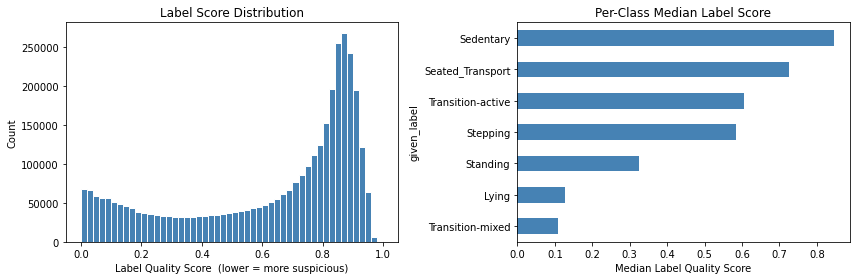

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(label_issues["label_score"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Label Quality Score  (lower = more suspicious)")
axes[0].set_ylabel("Count")
axes[0].set_title("Label Score Distribution")

per_class = (
    label_issues.groupby("given_label")["label_score"]
    .median()
    .sort_values()
)
per_class.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Median Label Quality Score")
axes[1].set_title("Per-Class Median Label Score")

plt.tight_layout()
plt.savefig("cleanlab_label_scores.png", dpi=120, bbox_inches="tight")
plt.show()

### 8d. Outlier Issues

In [17]:
outlier_issues = lab.get_issues("outlier").copy()
outlier_issues["given_label"] = [LABEL_NAMES[l] for l in labels]

n_outliers = outlier_issues["is_outlier_issue"].sum()
print(f"Outliers: {n_outliers} / {len(labels)}  ({100*n_outliers/len(labels):.1f}%)")
outlier_issues[outlier_issues["is_outlier_issue"]].sort_values("outlier_score").head(10)

Outliers: 74259 / 3532068  (2.1%)


,is_outlier_issue,outlier_score,given_label
2146077,True,2.027713e-08,Transition-active
241029,True,2.067554e-08,Sedentary
2732719,True,9.656336e-08,Transition-mixed
857502,True,1.103364e-07,Stepping
1870788,True,1.961278e-07,Sedentary
2844036,True,2.544258e-07,Sedentary
2287397,True,2.689977e-07,Sedentary
89632,True,2.744127e-07,Lying
3294712,True,2.878361e-07,Standing
685571,True,3.530566e-07,Standing


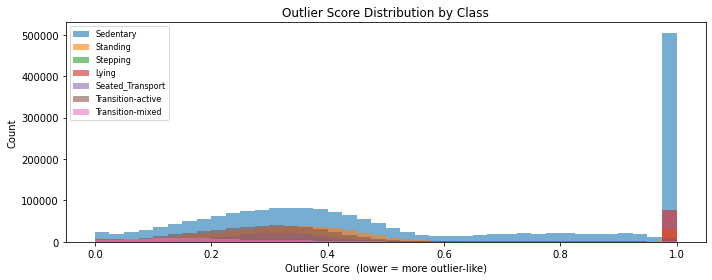

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, name in LABEL_NAMES.items():
    scores = outlier_issues[outlier_issues["given_label"] == name]["outlier_score"]
    ax.hist(scores, bins=40, alpha=0.6, label=name)
ax.set_xlabel("Outlier Score  (lower = more outlier-like)")
ax.set_ylabel("Count")
ax.set_title("Outlier Score Distribution by Class")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("cleanlab_outlier_scores.png", dpi=120, bbox_inches="tight")
plt.show()

### 8e. Near-Duplicate Issues

In [19]:
near_dup_issues = lab.get_issues("near_duplicate").copy()
near_dup_issues["given_label"] = [LABEL_NAMES[l] for l in labels]

n_dups = near_dup_issues["is_near_duplicate_issue"].sum()
print(f"Near-duplicates: {n_dups} / {len(labels)}  ({100*n_dups/len(labels):.1f}%)")
near_dup_issues[near_dup_issues["is_near_duplicate_issue"]].sort_values("near_duplicate_score").head(10)

Near-duplicates: 887327 / 3532068  (25.1%)


,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor,given_label
353,True,0.0,"[355, 354, 357, 356]",0.0,Sedentary
2170745,True,0.0,"[2170742, 2170739, 2170737, 2170738, 2170741]",0.0,Sedentary
2170746,True,0.0,"[2170742, 2170739, 2170737, 2170738, 2170741]",0.0,Sedentary
2170747,True,0.0,"[2170742, 2170739, 2170737, 2170738, 2170741]",0.0,Sedentary
2170748,True,0.0,"[2170742, 2170739, 2170737, 2170738, 2170741]",0.0,Sedentary
2170751,True,0.0,"[2170752, 2170753]",0.0,Sedentary
2170752,True,0.0,"[2170751, 2170753]",0.0,Sedentary
2170753,True,0.0,"[2170751, 2170752]",0.0,Sedentary
2170757,True,0.0,"[2170760, 2170762, 2170759, 2170758, 2170761, ...",0.0,Sedentary
2170758,True,0.0,"[2170760, 2170762, 2170759, 2170757, 2170761, ...",0.0,Sedentary


### 8f. Inspect Flagged Samples

Raw feature values for the most suspicious label issues.

In [20]:
top_idx = label_issues.sort_values("label_score").head(10).index

inspect = df.iloc[top_idx][FEATURE_COLS + ["truth"]].copy()
inspect.insert(0, "given_label",     label_issues.loc[top_idx, "given_label"].values)
inspect.insert(1, "predicted_label", label_issues.loc[top_idx, "predicted_label"].values)
inspect.insert(2, "label_score",     label_issues.loc[top_idx, "label_score"].values)

summary_cols = ["given_label", "predicted_label", "label_score",
                "mean_x", "mean_y", "mean_z", "mean_vm",
                "std_x",  "std_y",  "std_z",  "std_vm"]
inspect[summary_cols].round(3)


,given_label,predicted_label,label_score,mean_x,mean_y,mean_z,mean_vm,std_x,std_y,std_z,std_vm
257588,Standing,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257471,Transition-active,2,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257472,Stepping,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257626,Transition-active,2,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257475,Stepping,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257476,Stepping,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257618,Transition-active,2,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257480,Standing,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257484,Stepping,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0
257612,Stepping,5,0.0,0.305,0.566,0.746,0.985,0.0,0.0,0.0,0.0


## 9. Save All Issues

In [33]:
all_issues = lab.get_issues().copy()
all_issues["given_label"] = [LABEL_NAMES[l] for l in labels]

# Attach a few key features for convenient downstream analysis
for col in ["mean_vm", "std_vm", "domfreq_vm", "specenergy_vm"]:
    all_issues[col] = df[col].values

out_path = "/niddk-data-central/mae_hr/RISE_PH/cleanlab_issues_tabular.csv"
all_issues.to_csv(out_path)
print(f"Saved: {out_path}  ({len(all_issues)} rows, {len(all_issues.columns)} cols)")
all_issues.head()

Saved: /niddk-data-central/mae_hr/RISE_PH/cleanlab_issues_tabular.csv  (14000 rows, 17 cols)


,is_label_issue,label_score,is_outlier_issue,outlier_score,is_near_duplicate_issue,near_duplicate_score,is_non_iid_issue,non_iid_score,is_class_imbalance_issue,class_imbalance_score,is_underperforming_group_issue,underperforming_group_score,given_label,mean_vm,std_vm,domfreq_vm,specenergy_vm
0,True,0.334165,False,0.409451,False,0.601769,False,0.942003,False,1.0,False,1.0,Standing,1.042138,0.037311,0,391229.290520
1,True,0.152118,True,0.000013,False,0.999991,False,0.856388,False,1.0,False,1.0,Standing,1.000940,0.000605,0,360676.856802
2,False,0.923294,False,0.417426,False,0.580266,False,0.809867,False,1.0,False,1.0,Seated_Transport,1.020880,0.071036,0,376099.122962
3,False,0.485657,False,0.357990,False,0.669742,False,0.939357,False,1.0,False,1.0,Standing,1.004759,0.014220,0,363471.226196
4,False,0.969614,False,0.356371,False,0.651066,False,0.909848,False,1.0,False,1.0,Seated_Transport,0.996161,0.046897,0,357636.860424
